# Parte 2: Limpieza de Datos y Curación

Tomando las decisiones extraídas del EDA (notebook 01), en este notebook aplicamos filtros reproducibles y sistemáticos.

## Objetivos
1. Eliminar columnas con **Data Leakage** identificadas en el EDA.
2. Aplicar filtros de calidad por **reglas de negocio** (outliers lógicos).
3. Manejar **valores nulos** (imputación o eliminación justificada).
4. Agrupar categorías de baja frecuencia en **`Other`**.
5. Traspasar la lógica a funciones limpias que irán a `src/features/build_features.py`.

> 💡 **Nota**: Las funciones aquí definidas son los prototipos. El código final modular vive en `src/`.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
from dotenv import load_dotenv
load_dotenv('../.env')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Setup completado.')

✅ Setup completado.


---
## 1. Carga de la Muestra y Configuración del EDA

Usamos la misma muestra del notebook 01 para validar la limpieza antes de aplicarla en producción.

In [3]:
# Cargar configuración exportada por el notebook 01
with open('../data/interim/eda_config.json', 'r') as f:
    eda_config = json.load(f)

LEAKAGE_COLUMNS = eda_config['leakage_cols']
TARGET = eda_config['target']
AMOUNT_MIN = eda_config['amount_min']
AMOUNT_MAX = eda_config['amount_max']

print(f'Target: {TARGET}')
print(f'Rango válido de target: ${AMOUNT_MIN} - ${AMOUNT_MAX}')
print(f'Columnas de leakage a eliminar: {len(LEAKAGE_COLUMNS)}')

Target: total_amount
Rango válido de target: $2.5 - $500.0
Columnas de leakage a eliminar: 16


In [4]:
from src.data.ingestion import fetch_sample

# Muestra más pequeña para validar la limpieza (suficiente con 0.3%)
query = "SELECT * FROM analytics.train_set"
df_raw = fetch_sample(query, sample_prob=0.3)

print(f'✅ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Columnas: {list(df_raw.columns)}')

✅ Dataset cargado: 2,333,429 filas × 33 columnas
Columnas: ['pickup_datetime', 'dropoff_datetime', 'pu_location_id', 'do_location_id', 'vendor_name', 'rate_code_id', 'rate_code_desc', 'payment_type_desc', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'run_id', 'ingested_at_utc', 'pu_zone', 'pu_borough', 'do_zone', 'do_borough', 'month', 'year', 'source_service', 'pickup_date', 'pickup_hour', 'dropoff_date', 'dropoff_hour', 'day_of_week']


---
## 2. Función: Eliminar Columnas de Data Leakage

In [5]:
def remove_leakage_columns(df: pd.DataFrame, leakage_cols: list) -> pd.DataFrame:
    """
    Elimina las columnas que constituyen Data Leakage:
    - Componentes matemáticos del target (fare_amount, tip_amount, etc.)
    - Información solo disponible al finalizar el viaje (dropoff_datetime, trip_duration_min)
    - IDs de trazabilidad interna (run_id, ingested_at_utc)
    
    Args:
        df: DataFrame con todas las columnas de la OBT.
        leakage_cols: lista de columnas a eliminar.
    
    Returns:
        DataFrame sin las columnas de leakage.
    """
    cols_to_drop = [c for c in leakage_cols if c in df.columns]
    df_clean = df.drop(columns=cols_to_drop)
    print(f'Columnas eliminadas (leakage): {len(cols_to_drop)}')
    print(f'  → {cols_to_drop}')
    print(f'Columnas restantes: {df_clean.shape[1]}')
    return df_clean

# Aplicar
df_no_leakage = remove_leakage_columns(df_raw, LEAKAGE_COLUMNS)
df_no_leakage.head(2)

Columnas eliminadas (leakage): 12
  → ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'congestion_surcharge', 'airport_fee', 'dropoff_datetime', 'dropoff_date', 'dropoff_hour', 'run_id', 'ingested_at_utc']
Columnas restantes: 21


,pickup_datetime,pu_location_id,do_location_id,vendor_name,rate_code_id,rate_code_desc,payment_type_desc,passenger_count,trip_distance,improvement_surcharge,...,pu_zone,pu_borough,do_zone,do_borough,month,year,source_service,pickup_date,pickup_hour,day_of_week
0,2015-02-04 20:21:30,142,236,"Curb Mobility, LLC",1.0,Standard rate,Flex Fare trip,1.0,2.0,0.3,...,Lincoln Square East,Manhattan,Upper East Side North,Manhattan,2,2015,yellow,2015-02-04,20,3
1,2015-02-18 08:49:33,229,137,"Creative Mobile Technologies, LLC",1.0,Standard rate,Flex Fare trip,2.0,1.0,0.3,...,Sutton Place/Turtle Bay North,Manhattan,Kips Bay,Manhattan,2,2015,yellow,2015-02-18,8,3


---
## 3. Función: Filtros de Calidad por Reglas de Negocio

In [6]:
def apply_business_filters(
    df: pd.DataFrame,
    amount_min: float = 2.50,
    amount_max: float = 500.0,
    distance_max: float = 200.0,
    passenger_max: int = 6
) -> pd.DataFrame:
    """
    Aplica filtros basados en lógica de negocio del dominio NYC Taxi.
    
    Reglas:
        - total_amount: entre $2.50 (tarifa mínima NYC) y $500 (razonable)
        - trip_distance: mayor a 0 (viaje real) y < 200 millas (dentro del área)
        - passenger_count: entre 1 y 6 (capacidad de un taxi)
    
    Args:
        df: DataFrame post-limpieza de leakage.
        amount_min: mínimo de total_amount en dólares.
        amount_max: máximo de total_amount en dólares.
        distance_max: máximo de trip_distance en millas.
        passenger_max: máximo de pasajeros.
    
    Returns:
        DataFrame filtrado.
    """
    n_before = len(df)
    mask = pd.Series(True, index=df.index)
    
    # Filtros del target
    mask &= df['total_amount'] > amount_min
    mask &= df['total_amount'] <= amount_max
    
    # Filtros de distancia
    if 'trip_distance' in df.columns:
        mask &= df['trip_distance'] > 0
        mask &= df['trip_distance'] <= distance_max
    
    # Filtros de pasajeros
    if 'passenger_count' in df.columns:
        mask &= df['passenger_count'].between(1, passenger_max)
    
    # Eliminar fechas de pickup nulas (sin fecha, no se puede predecir)
    if 'pickup_datetime' in df.columns:
        mask &= df['pickup_datetime'].notna()
    
    df_filtered = df[mask].copy()
    n_after = len(df_filtered)
    removed = n_before - n_after
    
    print(f'Filas antes: {n_before:,}')
    print(f'Filas después: {n_after:,}')
    print(f'Removidas: {removed:,} ({removed/n_before*100:.2f}%)')
    
    return df_filtered

df_filtered = apply_business_filters(df_no_leakage, AMOUNT_MIN, AMOUNT_MAX)
df_filtered.head(2)

Filas antes: 2,333,429
Filas después: 2,271,806
Removidas: 61,623 (2.64%)


,pickup_datetime,pu_location_id,do_location_id,vendor_name,rate_code_id,rate_code_desc,payment_type_desc,passenger_count,trip_distance,improvement_surcharge,...,pu_zone,pu_borough,do_zone,do_borough,month,year,source_service,pickup_date,pickup_hour,day_of_week
0,2015-02-04 20:21:30,142,236,"Curb Mobility, LLC",1.0,Standard rate,Flex Fare trip,1.0,2.0,0.3,...,Lincoln Square East,Manhattan,Upper East Side North,Manhattan,2,2015,yellow,2015-02-04,20,3
1,2015-02-18 08:49:33,229,137,"Creative Mobile Technologies, LLC",1.0,Standard rate,Flex Fare trip,2.0,1.0,0.3,...,Sutton Place/Turtle Bay North,Manhattan,Kips Bay,Manhattan,2,2015,yellow,2015-02-18,8,3


---
## 4. Función: Manejo de Nulos

In [ ]:
# Perfil de nulos post-filtros
null_pct = (df_filtered.isnull().sum() / len(df_filtered) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print('=== NULOS POST-FILTROS ===')
if len(null_pct) > 0:
    print(null_pct.to_string())
else:
    print('No quedan nulos después de los filtros de negocio.')

=== NULOS POST-FILTROS ===
No quedan nulos después de los filtros de negocio.


In [7]:
def handle_nulls(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estrategia de manejo de nulos por columna.
    
    Estrategias usadas:
        - passenger_count: imputar con la mediana (viaje típico = 1 pasajero)
        - rate_code_id / rate_code_desc: imputar con 'Unknown' / 1 (Standard)
        - pu_zone / do_zone / pu_borough / do_borough: imputar con 'Unknown'
        - Filas con nulos en columnas críticas: eliminar
    
    Args:
        df: DataFrame filtrado.
    
    Returns:
        DataFrame sin nulos relevantes.
    """
    df = df.copy()
    
    # Imputaciones numéricas
    if 'passenger_count' in df.columns:
        median_passengers = df['passenger_count'].median()
        n_null = df['passenger_count'].isnull().sum()
        df['passenger_count'] = df['passenger_count'].fillna(median_passengers)
        if n_null > 0:
            print(f'passenger_count: {n_null:,} nulos imputados con mediana ({median_passengers:.0f})')
    
    if 'rate_code_id' in df.columns:
        n_null = df['rate_code_id'].isnull().sum()
        df['rate_code_id'] = df['rate_code_id'].fillna(1)  # Standard rate
        if n_null > 0:
            print(f'rate_code_id: {n_null:,} nulos imputados con 1 (Standard)')
    
    # Imputaciones categóricas
    for cat_col in ['rate_code_desc', 'payment_type_desc', 'vendor_name']:
        if cat_col in df.columns:
            n_null = df[cat_col].isnull().sum()
            df[cat_col] = df[cat_col].fillna('Unknown')
            if n_null > 0:
                print(f'{cat_col}: {n_null:,} nulos → "Unknown"')
    
    for geo_col in ['pu_zone', 'do_zone', 'pu_borough', 'do_borough']:
        if geo_col in df.columns:
            n_null = df[geo_col].isnull().sum()
            df[geo_col] = df[geo_col].fillna('Unknown')
            if n_null > 0:
                print(f'{geo_col}: {n_null:,} nulos → "Unknown"')
    
    # Verificar
    remaining_nulls = df.isnull().sum().sum()
    print(f'\nNulos restantes en el dataset: {remaining_nulls:,}')
    
    return df

df_no_nulls = handle_nulls(df_filtered)
print(f'\nShape final: {df_no_nulls.shape}')


Nulos restantes en el dataset: 0

Shape final: (2274211, 24)


---
## 5. Función: Agrupamiento de Categorías de Baja Frecuencia

In [8]:
def group_rare_categories(
    df: pd.DataFrame,
    col: str,
    top_n: int = 50,
    other_label: str = 'Other'
) -> pd.DataFrame:
    """
    Agrupa las categorías poco frecuentes en un valor 'Other' para reducir
    la cardinalidad y evitar overfitting en variables como pu_zone / do_zone
    que pueden tener 250+ valores únicos.
    
    Args:
        df: DataFrame.
        col: Nombre de la columna categórica a agrupar.
        top_n: Número de categorías top a mantener.
        other_label: Etiqueta para las categorías agrupadas.
    
    Returns:
        DataFrame con la columna modificada.
    """
    if col not in df.columns:
        return df
    
    df = df.copy()
    n_unique_before = df[col].nunique()
    
    top_categories = df[col].value_counts().nlargest(top_n).index
    df[col] = df[col].where(df[col].isin(top_categories), other=other_label)
    
    n_unique_after = df[col].nunique()
    print(f'{col}: {n_unique_before} → {n_unique_after} categorías (top {top_n} + Other)')
    
    return df

# Aplicar a zonas de alta cardinalidad
df_cleaned = df_no_nulls.copy()

for zone_col in ['pu_zone', 'do_zone']:
    df_cleaned = group_rare_categories(df_cleaned, zone_col, top_n=50)

print(f'\nShape: {df_cleaned.shape}')

pu_zone: 259 → 51 categorías (top 50 + Other)
do_zone: 261 → 51 categorías (top 50 + Other)

Shape: (2274211, 24)


---
## 6. Función: Conversión de Tipos

In [9]:
def cast_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Optimiza los tipos de datos para reducir uso de memoria y
    asegurar consistencia antes del pipeline de transformación.
    
    - pickup_datetime → datetime64
    - Columnas enteras → int32 (ahorra memoria vs int64)
    - Columnas float → float32
    - Columnas categóricas de baja cardinalidad → category
    """
    df = df.copy()
    
    # Fechas
    if 'pickup_datetime' in df.columns:
        df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
    
    # Enteros
    int_cols = ['passenger_count', 'pu_location_id', 'do_location_id',
                'rate_code_id', 'pickup_hour', 'day_of_week', 'month', 'year']
    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype('int32')
    
    # Flotantes
    float_cols = ['trip_distance', 'total_amount']
    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype('float32')
    
    # Categóricas de baja cardinalidad
    low_card_cats = ['vendor_name', 'rate_code_desc', 'payment_type_desc',
                     'pu_borough', 'do_borough', 'source_service', 'service_type']
    for col in low_card_cats:
        if col in df.columns:
            df[col] = df[col].astype('category')
    
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'Memoria post-optimización: {mem_mb:.1f} MB')
    print(df.dtypes.to_string())
    
    return df

df_typed = cast_dtypes(df_cleaned)
print(f'\nShape final: {df_typed.shape}')

Memoria post-optimización: 391.7 MB
pickup_datetime          datetime64[us]
pu_location_id                    int32
do_location_id                    int32
vendor_name                    category
rate_code_id                      int32
rate_code_desc                 category
payment_type_desc              category
passenger_count                   int32
trip_distance                   float32
improvement_surcharge           float64
total_amount                    float32
source_year                       int64
source_month                      int64
service_type                   category
pu_zone                             str
pu_borough                     category
do_zone                             str
do_borough                     category
pickup_date                      object
pickup_hour                       int32
day_of_week                       int32
month                             int32
year                              int32
source_service                 category

Sha

---
## 7. Función: Pipeline Completo de Limpieza

Encadenamos todas las funciones anteriores en una sola función `clean_dataframe`, que es exactamente lo que irá a `src/features/build_features.py`.

In [ ]:
def clean_dataframe(
    df: pd.DataFrame,
    leakage_cols: list = None,
    amount_min: float = 2.50,
    amount_max: float = 500.0,
) -> pd.DataFrame:
    """
    Pipeline completo de limpieza de datos. Encadena:
      1. Eliminación de columnas con Data Leakage
      2. Filtros de reglas de negocio (outliers lógicos)
      3. Manejo de nulos (imputación o eliminación)
      4. Agrupamiento de categorías raras
      5. Optimización de tipos de datos
    
    Esta función es la que se traslada a src/features/build_features.py.
    
    Args:
        df: DataFrame crudo de la OBT.
        leakage_cols: Lista de columnas a eliminar por leakage.
        amount_min: Mínimo de total_amount válido.
        amount_max: Máximo de total_amount válido.
    
    Returns:
        DataFrame limpio, listo para feature engineering.
    """
    if leakage_cols is None:
        leakage_cols = LEAKAGE_COLUMNS
    
    print('--- PASO 1: Filtros de negocio ---')
    df = apply_business_filters(df, amount_min, amount_max)
    \n
    print('\\n--- PASO 2: Eliminando leakage ---')
    df = remove_leakage_columns(df, leakage_cols)
    
    print('\n--- PASO 3: Manejo de nulos ---')
    df = handle_nulls(df)
    
    print('\n--- PASO 4: Cardinalidad categórica ---')
    for zone_col in ['pu_zone', 'do_zone']:
        df = group_rare_categories(df, zone_col, top_n=50)
    
    print('\n--- PASO 5: Optimización de tipos ---')
    df = cast_dtypes(df)
    
    print(f'\n✅ Limpieza completada. Shape: {df.shape}')
    return df

# Validar sobre la muestra
df_clean = clean_dataframe(df_raw)
df_clean.head(3)

--- PASO 1: Eliminando leakage ---
Columnas eliminadas (leakage): 15
  → ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'congestion_surcharge', 'airport_fee', 'tip_pct', 'dropoff_datetime', 'dropoff_date', 'dropoff_hour', 'trip_duration_min', 'avg_speed_mph', 'run_id', 'ingested_at_utc']
Columnas restantes: 24

--- PASO 2: Filtros de negocio ---
Filas antes: 2,335,827
Filas después: 2,274,211
Removidas: 61,616 (2.64%)

--- PASO 3: Manejo de nulos ---

Nulos restantes en el dataset: 0

--- PASO 4: Cardinalidad categórica ---
pu_zone: 259 → 51 categorías (top 50 + Other)
do_zone: 261 → 51 categorías (top 50 + Other)

--- PASO 5: Optimización de tipos ---
Memoria post-optimización: 391.7 MB
pickup_datetime          datetime64[us]
pu_location_id                    int32
do_location_id                    int32
vendor_name                    category
rate_code_id                      int32
rate_code_desc                 category
payment_type_desc              category
pass

,pickup_datetime,pu_location_id,do_location_id,vendor_name,rate_code_id,rate_code_desc,payment_type_desc,passenger_count,trip_distance,improvement_surcharge,...,pu_zone,pu_borough,do_zone,do_borough,pickup_date,pickup_hour,day_of_week,month,year,source_service
0,2015-02-04 09:43:33,224,87,Creative Mobile Technologies,1,Standard rate,Cash,2,3.40,0.3,...,Other,Manhattan,Financial District North,Manhattan,2015-02-04,9,3,2,2015,yellow
1,2015-02-17 17:25:33,234,79,VeriFone Inc.,1,Standard rate,Credit card,1,1.42,0.3,...,Union Sq,Manhattan,East Village,Manhattan,2015-02-17,17,2,2,2015,yellow
2,2015-02-04 09:11:43,68,100,VeriFone Inc.,1,Standard rate,Credit card,1,1.24,0.3,...,East Chelsea,Manhattan,Garment District,Manhattan,2015-02-04,9,3,2,2015,yellow


---
## 8. Validación: Verificar que No Hay Leakage Residual

In [11]:
print('=== VERIFICACIÓN DE LEAKAGE ===')
residual_leakage = [c for c in LEAKAGE_COLUMNS if c in df_clean.columns]

if residual_leakage:
    print(f'⚠️  PROBLEMA: Aún hay columnas de leakage: {residual_leakage}')
else:
    print('✅ Ninguna columna de leakage presente en el dataset limpio.')

print(f'\n=== VERIFICACIÓN DE NULOS ===')
total_nulls = df_clean.isnull().sum().sum()
if total_nulls > 0:
    print(f'⚠️  {total_nulls} nulos presentes:')
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
else:
    print('✅ Cero nulos en el dataset limpio.')

print(f'\n=== VERIFICACIÓN DE RANGOS ===')
print(f'total_amount min: ${df_clean["total_amount"].min():.2f} (esperado > $2.50)')
print(f'total_amount max: ${df_clean["total_amount"].max():.2f} (esperado <= $500)')
if 'trip_distance' in df_clean.columns:
    print(f'trip_distance min: {df_clean["trip_distance"].min():.3f} (esperado > 0)')
if 'passenger_count' in df_clean.columns:
    print(f'passenger_count: {df_clean["passenger_count"].min()} - {df_clean["passenger_count"].max()} (esperado 1-6)')

=== VERIFICACIÓN DE LEAKAGE ===
✅ Ninguna columna de leakage presente en el dataset limpio.

=== VERIFICACIÓN DE NULOS ===
✅ Cero nulos en el dataset limpio.

=== VERIFICACIÓN DE RANGOS ===
total_amount min: $2.80 (esperado > $2.50)
total_amount max: $499.30 (esperado <= $500)
trip_distance min: 0.010 (esperado > 0)
passenger_count: 1 - 6 (esperado 1-6)


---
## 9. Comparativa Visual: Antes vs Después

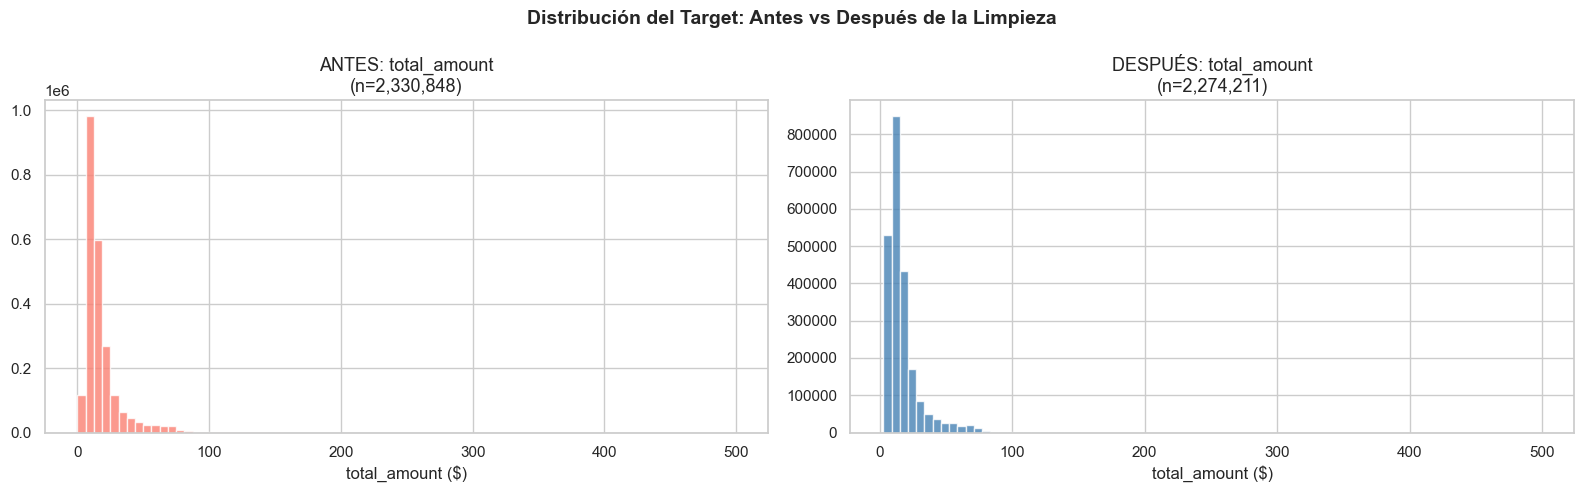

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Antes de la limpieza
df_raw_valid = df_raw[(df_raw['total_amount'] > 0) & (df_raw['total_amount'] < 500)]
axes[0].hist(df_raw_valid['total_amount'], bins=80, color='salmon', edgecolor='white', alpha=0.8)
axes[0].set_title(f'ANTES: total_amount\n(n={len(df_raw_valid):,})', fontsize=13)
axes[0].set_xlabel('total_amount ($)')

# Después de la limpieza
axes[1].hist(df_clean['total_amount'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title(f'DESPUÉS: total_amount\n(n={len(df_clean):,})', fontsize=13)
axes[1].set_xlabel('total_amount ($)')

plt.suptitle('Distribución del Target: Antes vs Después de la Limpieza', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/interim/02_before_after_cleaning.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 10. Guardar Dataset Limpio Intermedio

In [15]:
# Guardar muestra limpia para el notebook 03
# Usando CSV en lugar de parquet (pyarrow bloqueado por Windows Defender)
os.makedirs('../data/interim', exist_ok=True)
clean_path = '../data/interim/clean_sample.csv'
df_clean.to_csv(clean_path, index=False)
print(f'✅ Dataset limpio guardado en: {clean_path}')
print(f'   Filas: {len(df_clean):,} | Columnas: {df_clean.shape[1]}')
print(f'   Columnas disponibles: {list(df_clean.columns)}')

✅ Dataset limpio guardado en: ../data/interim/clean_sample.csv
   Filas: 2,274,211 | Columnas: 24
   Columnas disponibles: ['pickup_datetime', 'pu_location_id', 'do_location_id', 'vendor_name', 'rate_code_id', 'rate_code_desc', 'payment_type_desc', 'passenger_count', 'trip_distance', 'improvement_surcharge', 'total_amount', 'source_year', 'source_month', 'service_type', 'pu_zone', 'pu_borough', 'do_zone', 'do_borough', 'pickup_date', 'pickup_hour', 'day_of_week', 'month', 'year', 'source_service']


---
## Resumen de Acciones Realizadas

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Eliminación de leakage | Removidas componentes del target + info post-viaje |
| 2 | Filtros de negocio | Total amount: $2.50–$500, distancia > 0, pasajeros 1–6 |
| 3 | Manejo de nulos | Imputación mediana para numéricos, 'Unknown' para categóricos |
| 4 | Cardinalidad | pu_zone y do_zone reducidas a top 50 + Other |
| 5 | Tipos de datos | int32/float32/category para optimizar memoria |\n
\n
**📦 Próximo paso**: El notebook 03 toma `data/interim/clean_sample.parquet` y construye nuevas features espacio-temporales.

---
## 11. Ejecución de la Limpieza Directamente en Snowflake (Pushdown)

Tal como lo requiere el pipeline, la lógica estructural definida arriba ha sido volcada a un query SQL (`src/data/sql/03_clean_obt.sql`). Ejecutamos este script en el clúster de Snowflake para que la tabla base quede limpia sin descargar datos localmente y luego lo actualizamos en la vista de los splits.

In [ ]:
from src.data.ingestion import get_snowflake_connection

# Leer el script SQL
with open('../src/data/sql/03_clean_obt.sql', 'r', encoding='utf-8') as f:
    sql_script = f.read()

conn = get_snowflake_connection()
cursor = conn.cursor()
try:
    print('Ejecutando limpieza en Snowflake...')
    # Split por punto y coma y ejecutar
    for query in sql_script.split(';'):
        if query.strip():
            cursor.execute(query)
    print('✅ Tabla ANALYTICS.cleaned_obt_trips creada exitosamente en Snowflake.')
    
    # Actualizamos los splits para que apunten a la tabla limpia
    print('Actualizando splits (Train, Val, Test)...')
    with open('../src/data/sql/02_create_splits.sql', 'r', encoding='utf-8') as f:
        splits_script = f.read()
    for query in splits_script.split(';'):
        if query.strip():
            cursor.execute(query)
    print('✅ Vistas de splits actualizadas.')
except Exception as e:
    print(f'❌ Error: {e}')
finally:
    cursor.close()
    conn.close()